# Selecting a chisel

Start by loading `Dleto.jl`

In [1]:
include( "../../Sylvester.jl" )

Next we will make a small tensor with a know structure that will allow us to explore chiselling.  The following tensor has 5 rows, 5 columns, and 5 slices the last 2 of which are all zero.  This condition is known as a **degenerate** tensor, also known as **inconcise**.  The information in such tensor is clearly confined to the nonzero 3 x 3 x 3 block.  We can use many tools to detect this, chiseling is one tool.

In [3]:
deg_t = zeros(Float64, 5,5,5)
deg_t[1:3, 1:3, 1:3] .= rand(3,3,3)

3×3×3 view(::Array{Float64, 3}, 1:3, 1:3, 1:3) with eltype Float64:
[:, :, 1] =
 0.57483   0.719584   0.903629
 0.318089  0.50992    0.605342
 0.78873   0.0959535  0.194869

[:, :, 2] =
 0.0321916  0.0411586  0.68972
 0.583259   0.394231   0.199324
 0.15126    0.787786   0.337957

[:, :, 3] =
 0.027729  0.129691  0.171304
 0.281314  0.850452  0.20358
 0.786219  0.492586  0.0111766

Now let use hte universal chisel to begin exploring.  This is the default choice so calling `chisel` will get us going.

**Jargon Alert:** Dleto mean "chisel" and "spall" is the material that comes off a block when chiselling.  In tensors when we chisel we produce a list of scalars and a list of matrices.  The combination we call the spall.

In [4]:
spall = chisel(deg_t);

Computed 75 singular values, returning 10 smallest.


You see the default setting used only 10 of the available 75 values.  The value \(75=3\cdot 5^2\) coincides with being a 3-valent tensor with dimensions `(5,5,5)` so it will take 3 \(5\times 5\)-operators to manipulate for a total of 75 parameters.  However there are also \(125=5^3\) constraint equations so we should expect few solutions.  Thus as a practical improvement we estimate only 10 solutions will be found.  For data that has large degeneracies this can be an under estimate.  To explain the process let us increase the range to collect all of available values.

In [ ]:
spall = chisel(deg_t, max=75);

┌ Warning: No strict ticks found
└ @ PlotUtils /Users/algeboy/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/algeboy/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/algeboy/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/algeboy/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/algeboy/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/algeboy/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils /Users/algeboy/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


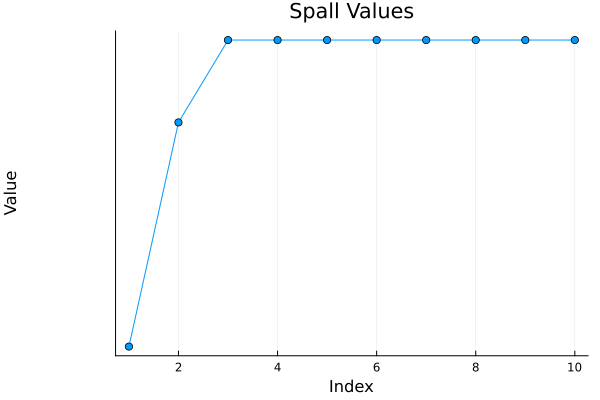

In [5]:
using Plots
plot(spall.values, marker=:circle, legend=false, xlabel="Index", ylabel="Value", title="Spall Values")